#### Problem Statement : FlavorSense is a machine learning classification problem that aims to predict a person's preferred taste based on their demographic, lifestyle, environmental, and culinary exposure characteristics.


#### Import all necessary libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sns.set_theme(style='darkgrid', palette='viridis')
import plotly.express as pe 
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\GitHub Projects\KNN-Classification\FlavorSense.csv")
df.head(2)

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,NaN,Salty
1,NaN,Night Owl,Heavy,Temperate,Asian,Sweet


#### Understand the dataset

In [3]:
df.shape

(10000, 6)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          9032 non-null   float64
 1   sleep_cycle                  9316 non-null   object 
 2   exercise_habits              9196 non-null   object 
 3   climate_zone                 9467 non-null   object 
 4   historical_cuisine_exposure  9346 non-null   object 
 5   preferred_taste              10000 non-null  object 
dtypes: float64(1), object(5)
memory usage: 468.9+ KB


In [5]:
df.describe()

,age
count,9032.000000
mean,43.552702
std,14.889327
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


In [6]:
df.dtypes

age                            float64
sleep_cycle                     object
exercise_habits                 object
climate_zone                    object
historical_cuisine_exposure     object
preferred_taste                 object
dtype: object

#### EDA

In [7]:
df.isna().sum()

age                            968
sleep_cycle                    684
exercise_habits                804
climate_zone                   533
historical_cuisine_exposure    654
preferred_taste                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3676)

In [9]:
df.replace(['NaN','',' ','@','#',0,'!','..','?'], np.nan, inplace=True)
df.head()

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,NaN,Salty
1,NaN,Night Owl,Heavy,Temperate,Asian,Sweet
2,46.0,Night Owl,Heavy,Cold,Mixed,Sour
3,32.0,Early Bird,Heavy,Cold,Mediterranean,Salty
4,60.0,Night Owl,Moderate,Dry,Mediterranean,Sour


#### In our dataset there are few missing values as well as 3676 duplicate values also.
#### With the help of simple Imputer we are going to replace all NAN values with median values

In [10]:
missing_values=(df.isna().sum()/len(df))*100
missing_values

age                            9.68
sleep_cycle                    6.84
exercise_habits                8.04
climate_zone                   5.33
historical_cuisine_exposure    6.54
preferred_taste                0.00
dtype: float64

#### Replacing missing values of categorical column with most frequent values

In [11]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')

df.loc[:,'sleep_cycle':'historical_cuisine_exposure']=si.fit_transform(df.loc[:,'sleep_cycle':'historical_cuisine_exposure'])

#### Replacing missing values of Numerical column with mean

In [12]:
df['age']= df['age'].fillna(float(df['age'].mean()))

### Now check all the missing values are replaced or not?

In [13]:
df.isna().sum()

age                            0
sleep_cycle                    0
exercise_habits                0
climate_zone                   0
historical_cuisine_exposure    0
preferred_taste                0
dtype: int64

### Boxlpot to check whether outliers are present or not?

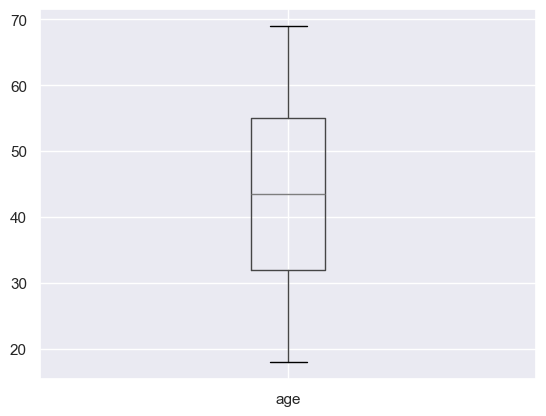

In [14]:
df.boxplot()
plt.show()

### Encoding

In [15]:
df.head(1)

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,Mediterranean,Salty


In [16]:
col=['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure','preferred_taste']
col

['sleep_cycle',
 'exercise_habits',
 'climate_zone',
 'historical_cuisine_exposure',
 'preferred_taste']

In [17]:
for i in col:
    print(f'\nUnique value in {i}')
    print(df[i].unique())


Unique value in sleep_cycle
['Irregular' 'Night Owl' 'Early Bird']

Unique value in exercise_habits
['Heavy' 'Moderate' 'Light']

Unique value in climate_zone
['Temperate' 'Cold' 'Dry' 'Tropical']

Unique value in historical_cuisine_exposure
['Mediterranean' 'Asian' 'Mixed']

Unique value in preferred_taste
['Salty' 'Sweet' 'Sour' 'Spicy']


In [18]:
oe=OrdinalEncoder()

col2=['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']
df[col2]=oe.fit_transform(df[col2])

In [19]:
le=LabelEncoder()
df['preferred_taste']=le.fit_transform(df['preferred_taste'])


In [20]:
df.head()

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.000000,1.0,0.0,2.0,1.0,0
1,43.552702,2.0,0.0,2.0,0.0,3
2,46.000000,2.0,0.0,0.0,2.0,1
3,32.000000,0.0,0.0,0.0,1.0,0
4,60.000000,2.0,2.0,1.0,1.0,1


#### Define X and Y

In [21]:
X=df.drop(columns=['preferred_taste'])
y=df['preferred_taste']

#### Scaling

In [22]:
sc=StandardScaler()
X=sc.fit_transform(X)
X

array([[ 8.79694998e-01,  9.06822323e-02, -1.30547526e+00,
         3.61120287e-01, -7.24562768e-03],
       [-5.02165904e-16,  1.29816868e+00, -1.30547526e+00,
         3.61120287e-01, -1.27840838e+00],
       [ 1.72959317e-01,  1.29816868e+00, -1.30547526e+00,
        -1.38595415e+00,  1.26391712e+00],
       ...,
       [ 9.50368566e-01, -1.11680422e+00,  1.10181823e+00,
        -1.38595415e+00, -7.24562768e-03],
       [ 1.44508354e+00,  9.06822323e-02, -1.01828514e-01,
         1.23465751e+00,  1.26391712e+00],
       [-8.16470636e-01, -1.11680422e+00, -1.30547526e+00,
         1.23465751e+00, -7.24562768e-03]])

#### Split dataset into training and testing set

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#### Identify the right KNN value

In [24]:
train_acc=[]
test_acc=[]

for i in range(2,20):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test,y_test))

In [25]:
test_acc

[0.8385,
 0.8625,
 0.868,
 0.869,
 0.874,
 0.871,
 0.8775,
 0.8775,
 0.8785,
 0.877,
 0.8785,
 0.882,
 0.878,
 0.8755,
 0.876,
 0.878,
 0.8765,
 0.875]

In [26]:
train_acc

[0.896375,
 0.90925,
 0.90175,
 0.90275,
 0.902,
 0.899125,
 0.8975,
 0.898875,
 0.898375,
 0.89875,
 0.8975,
 0.897875,
 0.89625,
 0.897,
 0.894875,
 0.8965,
 0.896625,
 0.896625]

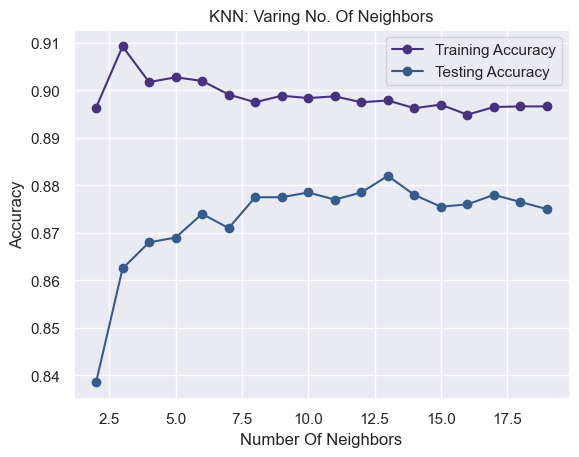

In [27]:
plt.plot(range(2,20),train_acc,label='Training Accuracy',marker='o')
plt.plot(range(2,20),test_acc,label='Testing Accuracy',marker='o')
plt.xlabel('Number Of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN: Varing No. Of Neighbors')
plt.legend()
plt.show()

### final Model Building

In [28]:
knn=KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)
ypred=knn.predict(X_test)
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       339
           1       0.83      0.86      0.85       741
           2       0.80      0.78      0.79        65
           3       0.92      0.86      0.89       855

    accuracy                           0.87      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.87      0.87      0.87      2000



In [29]:
print(f'Training accuracy: {knn.score(X_train, y_train)}')
print(f'Test accuracy: {knn.score(X_test, y_test)}')

Training accuracy: 0.90175
Test accuracy: 0.868


#### conclusion: 

The FlavorSense project successfully developed a **K-Nearest Neighbors (KNN) classification model** to predict an individual's preferred taste based on age, sleep cycle, exercise habits, climate zone, and historical cuisine exposure.

During the project, the dataset was cleaned by handling missing values and converting categorical features into numerical values. The features were then standardized because KNN is a distance-based algorithm. Different values of K were evaluated to identify the most suitable number of neighbors.

The final KNN model with **K = 4** achieved a **training accuracy of 90.18% and testing accuracy of 86.8%**. The classification report also shows good performance across the four taste classes—**Salty, Sweet, Sour, and Spicy**—with an overall weighted F1-score of approximately **0.87**.

The relatively small difference between training and testing accuracy indicates that the model generalizes reasonably well to unseen data. Therefore, the developed KNN model can be used as a baseline predictive system for personalized taste prediction and food recommendation applications.

Further improvement could be achieved through hyperparameter tuning, better categorical encoding, feature engineering, and comparison with other classification algorithms such as Random Forest, Decision Tree, Logistic Regression, and Gradient Boosting.
